# **2. Linear Transformations**

## What is a Linear Transformation?
A **linear transformation** is a function $T: \mathbb{R}^n \rightarrow \mathbb{R}^m$ that satisfies two properties:

1. **Additivity**: $T(\vec{u} + \vec{v}) = T(\vec{u}) + T(\vec{v})$
2. **Homogeneity**: $T(c \cdot \vec{v}) = c \cdot T(\vec{v})$

In other words, a linear transformation **preserves** vector addition and scalar multiplication.

### Intuition
Think of a linear transformation as "warping" space while keeping:
- The **origin** fixed
- **Lines** straight (not curved)
- **Parallel lines** parallel
- Grid lines **evenly spaced**

### Why Linear Transformations Matter in Data Science

| Application | How it uses linear transformations |
|-------------|-----------------------------------|
| **PCA** | Projects data onto new axes via rotation |
| **Neural Networks** | Each layer applies a linear transformation + activation |
| **Computer Graphics** | Rotation, scaling, shearing of objects |
| **Regression** | Linear model $y = Xw$ is a transformation |

In [1]:
# ===============================================
# UNDERSTANDING LINEAR TRANSFORMATIONS VIA
# BASIS VECTORS
# ===============================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

print("=" * 50)
print("BASIS VECTORS AND TRANSFORMATIONS")
print("=" * 50)

# Standard basis vectors
i_hat = np.array([1, 0])  # î
j_hat = np.array([0, 1])  # ĵ

print(f"\nStandard basis vectors:")
print(f"  î = {i_hat}")
print(f"  ĵ = {j_hat}")

# A linear transformation is completely determined
# by where it sends the basis vectors!
print("\nKey Insight: A linear transformation is completely")
print("determined by where it sends the basis vectors.")
print("These new basis vectors become the COLUMNS of the")
print("transformation matrix.")

BASIS VECTORS AND TRANSFORMATIONS

Standard basis vectors:
  î = [1 0]
  ĵ = [0 1]

Key Insight: A linear transformation is completely
determined by where it sends the basis vectors.
These new basis vectors become the COLUMNS of the
transformation matrix.


COMMON LINEAR TRANSFORMATIONS


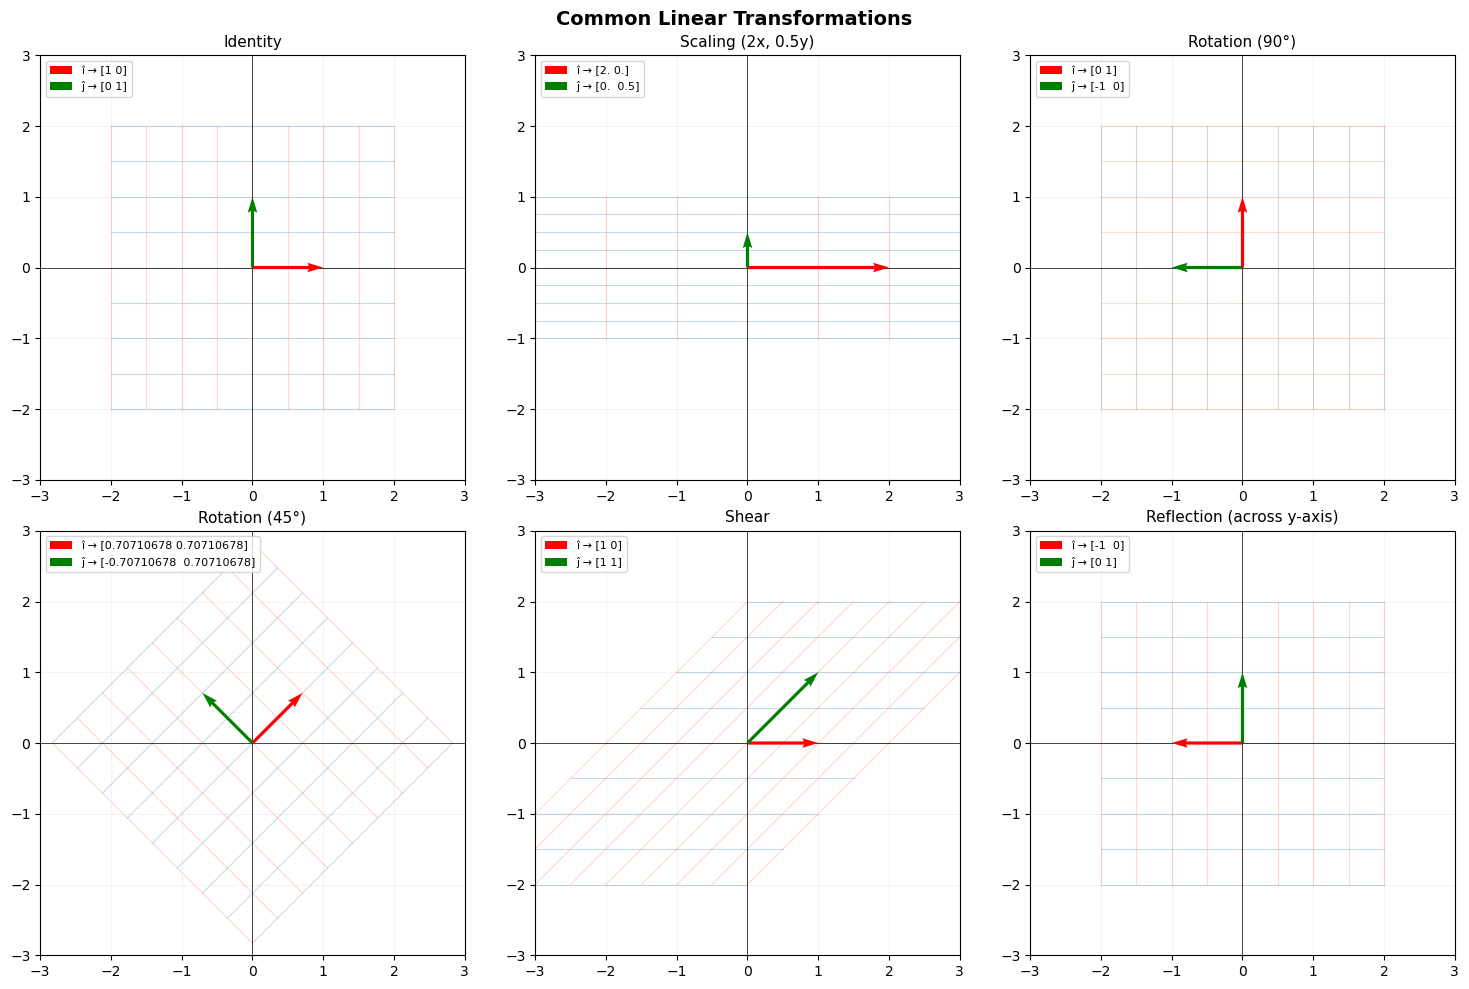


Identity:
  Matrix = 
[[1 0]
 [0 1]]

Scaling (2x, 0.5y):
  Matrix = 
[[2.  0. ]
 [0.  0.5]]

Rotation (90°):
  Matrix = 
[[ 0 -1]
 [ 1  0]]

Rotation (45°):
  Matrix = 
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Shear:
  Matrix = 
[[1 1]
 [0 1]]

Reflection (across y-axis):
  Matrix = 
[[-1  0]
 [ 0  1]]


In [2]:
# ===============================================
# COMMON LINEAR TRANSFORMATIONS
# ===============================================

print("=" * 50)
print("COMMON LINEAR TRANSFORMATIONS")
print("=" * 50)

# Helper function to visualize transformations
def plot_transformation(ax, matrix, title, original_grid=True):
    """Visualize how a 2x2 matrix transforms the standard grid."""
    # Create grid points
    t = np.linspace(-2, 2, 20)
    
    # Draw transformed grid lines
    for val in np.linspace(-2, 2, 9):
        # Horizontal lines (constant y)
        points_h = np.array([[x, val] for x in t])
        transformed_h = (matrix @ points_h.T).T
        ax.plot(transformed_h[:, 0], transformed_h[:, 1],
                'steelblue', alpha=0.3, linewidth=0.8)
        
        # Vertical lines (constant x)
        points_v = np.array([[val, y] for y in t])
        transformed_v = (matrix @ points_v.T).T
        ax.plot(transformed_v[:, 0], transformed_v[:, 1],
                'coral', alpha=0.3, linewidth=0.8)
    
    # Draw transformed basis vectors
    new_i = matrix @ np.array([1, 0])
    new_j = matrix @ np.array([0, 1])
    
    ax.quiver(0, 0, new_i[0], new_i[1], angles='xy', scale_units='xy', scale=1,
              color='red', linewidth=2, label=f'î → {new_i}', zorder=5)
    ax.quiver(0, 0, new_j[0], new_j[1], angles='xy', scale_units='xy', scale=1,
              color='green', linewidth=2, label=f'ĵ → {new_j}', zorder=5)
    
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc='upper left')

# Define transformations
identity = np.array([[1, 0], [0, 1]])
scaling = np.array([[2, 0], [0, 0.5]])
rotation_90 = np.array([[0, -1], [1, 0]])
shear = np.array([[1, 1], [0, 1]])
reflection = np.array([[-1, 0], [0, 1]])

theta = np.radians(45)
rotation_45 = np.array([[np.cos(theta), -np.sin(theta)],
                        [np.sin(theta),  np.cos(theta)]])

transforms = [
    (identity, 'Identity'),
    (scaling, 'Scaling (2x, 0.5y)'),
    (rotation_90, 'Rotation (90°)'),
    (rotation_45, 'Rotation (45°)'),
    (shear, 'Shear'),
    (reflection, 'Reflection (across y-axis)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (matrix, title) in zip(axes, transforms):
    plot_transformation(ax, matrix, title)

plt.suptitle('Common Linear Transformations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the matrices
for matrix, title in transforms:
    print(f"\n{title}:")
    print(f"  Matrix = \n{matrix}")

---
## Rotation Matrix

To rotate a vector by angle $\theta$ **counterclockwise**:

$$R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$$

### How it works:
- $\hat{i} = [1, 0]$ maps to $[\cos\theta, \sin\theta]$
- $\hat{j} = [0, 1]$ maps to $[-\sin\theta, \cos\theta]$

These are exactly the columns of the rotation matrix!

ROTATION MATRIX
  Rotate 0°: [3 1] → [3.00, 1.00]
  Rotate 30°: [3 1] → [2.10, 2.37]
  Rotate 45°: [3 1] → [1.41, 2.83]
  Rotate 60°: [3 1] → [0.63, 3.10]
  Rotate 90°: [3 1] → [-1.00, 3.00]
  Rotate 180°: [3 1] → [-3.00, -1.00]


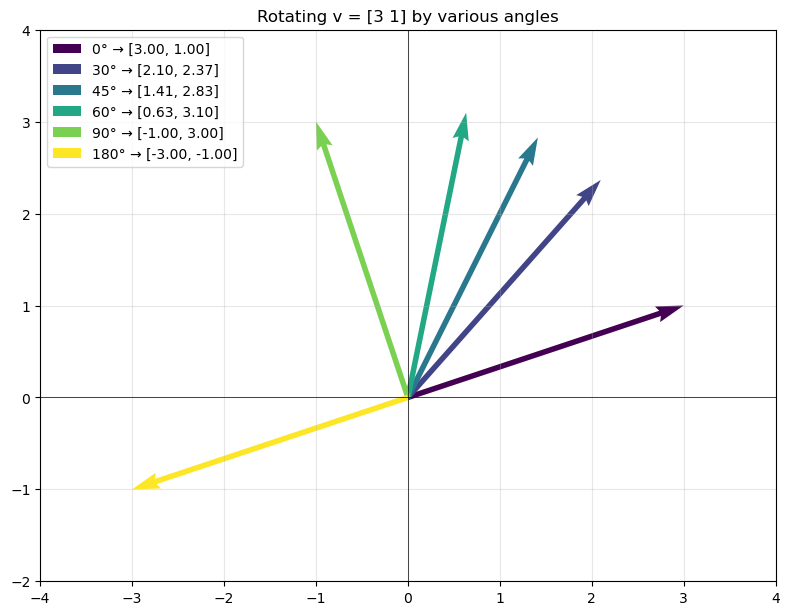

In [3]:
# ===============================================
# ROTATION MATRIX IN ACTION
# ===============================================

print("=" * 50)
print("ROTATION MATRIX")
print("=" * 50)

def rotation_matrix(angle_degrees):
    """Create a 2D rotation matrix for given angle in degrees."""
    theta = np.radians(angle_degrees)
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

v = np.array([3, 1])
angles = [0, 30, 45, 60, 90, 180]

fig, ax = plt.subplots(figsize=(8, 8))

colors = plt.cm.viridis(np.linspace(0, 1, len(angles)))

for angle, color in zip(angles, colors):
    R = rotation_matrix(angle)
    v_rotated = R @ v
    ax.quiver(0, 0, v_rotated[0], v_rotated[1], angles='xy', scale_units='xy',
              scale=1, color=color, linewidth=2,
              label=f'{angle}° → [{v_rotated[0]:.2f}, {v_rotated[1]:.2f}]')
    print(f"  Rotate {angle}°: {v} → [{v_rotated[0]:.2f}, {v_rotated[1]:.2f}]")

ax.set_xlim(-4, 4)
ax.set_ylim(-2, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title(f'Rotating v = {v} by various angles')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

---
## Composition of Transformations

Applying transformation $A$ followed by transformation $B$ is equivalent to applying the **product** $BA$:

$$T_{\text{combined}}(\vec{v}) = B(A(\vec{v})) = (BA)\vec{v}$$

> **Important**: Matrix multiplication is **not commutative** — $AB \neq BA$ in general! The order matters.

This is why in neural networks the order of layer transformations matters.

COMPOSITION OF TRANSFORMATIONS

Original vector: v = [1 1]

Scale then Rotate (R @ S):
  Matrix RS = 
[[ 1.4142 -0.7071]
 [ 1.4142  0.7071]]
  Result = [0.7071, 2.1213]

Rotate then Scale (S @ R):
  Matrix SR = 
[[ 1.4142 -1.4142]
 [ 0.7071  0.7071]]
  Result = [0.0000, 1.4142]

RS == SR? False
Order matters! Matrix multiplication is NOT commutative.


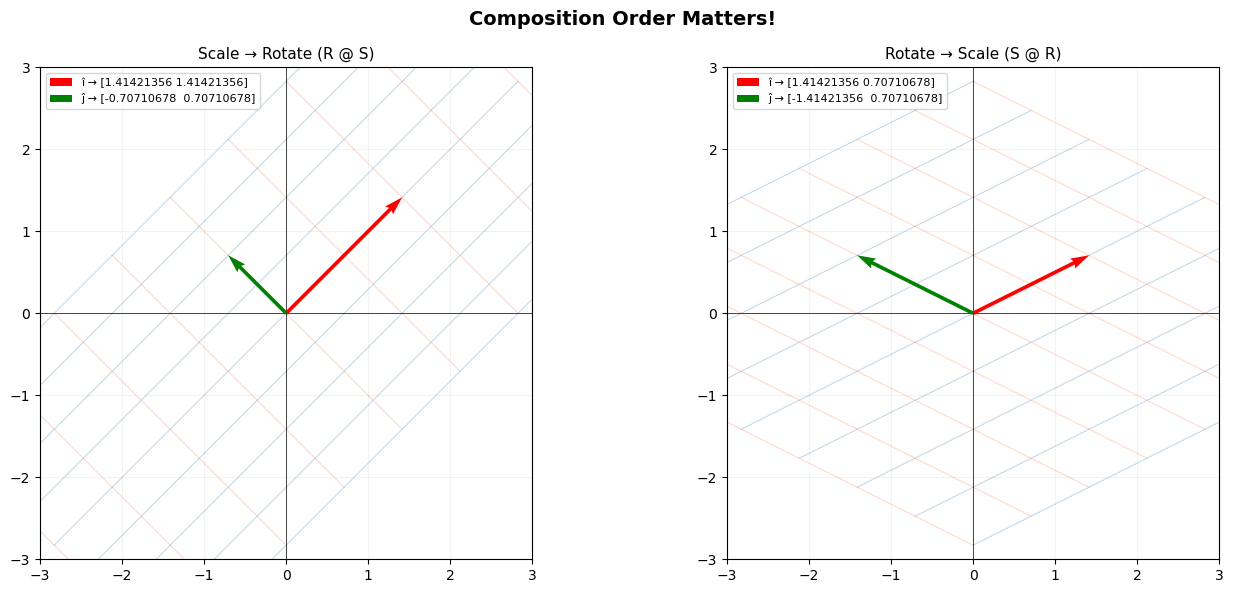

In [4]:
# ===============================================
# COMPOSITION OF TRANSFORMATIONS
# ===============================================

print("=" * 50)
print("COMPOSITION OF TRANSFORMATIONS")
print("=" * 50)

# Scale then Rotate vs Rotate then Scale
S = np.array([[2, 0], [0, 1]])       # Scale x by 2
R = rotation_matrix(45)               # Rotate 45°

v = np.array([1, 1])

# Order 1: Scale THEN Rotate → R @ S
RS = R @ S
result_1 = RS @ v

# Order 2: Rotate THEN Scale → S @ R
SR = S @ R
result_2 = SR @ v

print(f"\nOriginal vector: v = {v}")
print(f"\nScale then Rotate (R @ S):")
print(f"  Matrix RS = \n{np.round(RS, 4)}")
print(f"  Result = [{result_1[0]:.4f}, {result_1[1]:.4f}]")

print(f"\nRotate then Scale (S @ R):")
print(f"  Matrix SR = \n{np.round(SR, 4)}")
print(f"  Result = [{result_2[0]:.4f}, {result_2[1]:.4f}]")

print(f"\nRS == SR? {np.allclose(RS, SR)}")
print("Order matters! Matrix multiplication is NOT commutative.")

# Visualize both
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_transformation(axes[0], RS, 'Scale → Rotate (R @ S)')
plot_transformation(axes[1], SR, 'Rotate → Scale (S @ R)')

plt.suptitle('Composition Order Matters!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Inverse Transformations

If $A$ is a transformation matrix, its **inverse** $A^{-1}$ "undoes" the transformation:

$$A^{-1} \cdot A = A \cdot A^{-1} = I$$

where $I$ is the **identity matrix**.

A matrix is **invertible** (or nonsingular) if and only if its **determinant is non-zero**.

### When is a matrix NOT invertible?
- When it squishes space into a lower dimension (e.g., 2D → line)
- When the determinant is zero
- When the columns are linearly dependent

In [5]:
# ===============================================
# INVERSE TRANSFORMATIONS
# ===============================================

print("=" * 50)
print("INVERSE TRANSFORMATIONS")
print("=" * 50)

# A rotation can be undone by rotating the opposite direction
R_45 = rotation_matrix(45)
R_45_inv = np.linalg.inv(R_45)
R_neg45 = rotation_matrix(-45)

print(f"\nRotation 45°:")
print(f"{np.round(R_45, 4)}")
print(f"\nInverse (computed):")
print(f"{np.round(R_45_inv, 4)}")
print(f"\nRotation -45°:")
print(f"{np.round(R_neg45, 4)}")
print(f"\nAre they equal? {np.allclose(R_45_inv, R_neg45)}")

# Verify: A @ A_inv = I
identity = R_45 @ R_45_inv
print(f"\nR @ R⁻¹ = \n{np.round(identity, 10)}")
print("(This is the identity matrix)")

# Example of a NON-invertible matrix
print("\n" + "-" * 50)
print("NON-INVERTIBLE MATRIX")
print("-" * 50)

singular = np.array([[1, 2], [2, 4]])  # Columns are dependent
print(f"\nMatrix: \n{singular}")
print(f"Determinant = {np.linalg.det(singular):.4f}")
print("Determinant ≈ 0 → NOT invertible!")
print("This matrix squishes all of 2D space onto a line.")

try:
    inv = np.linalg.inv(singular)
    print(f"Inverse (numerically unstable): \n{inv}")
except np.linalg.LinAlgError:
    print("LinAlgError: Matrix is singular and cannot be inverted!")

INVERSE TRANSFORMATIONS

Rotation 45°:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Inverse (computed):
[[ 0.7071  0.7071]
 [-0.7071  0.7071]]

Rotation -45°:
[[ 0.7071  0.7071]
 [-0.7071  0.7071]]

Are they equal? True

R @ R⁻¹ = 
[[1. 0.]
 [0. 1.]]
(This is the identity matrix)

--------------------------------------------------
NON-INVERTIBLE MATRIX
--------------------------------------------------

Matrix: 
[[1 2]
 [2 4]]
Determinant = 0.0000
Determinant ≈ 0 → NOT invertible!
This matrix squishes all of 2D space onto a line.
LinAlgError: Matrix is singular and cannot be inverted!


---
## Summary

| Concept | Key Idea | Matrix Form |
|---------|----------|------------|
| **Linear Transformation** | Preserves addition & scalar multiplication | $T(\vec{v}) = A\vec{v}$ |
| **Rotation** | Rotates by angle $\theta$ | $R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$ |
| **Scaling** | Stretches/compresses axes | $\begin{bmatrix} s_x & 0 \\ 0 & s_y \end{bmatrix}$ |
| **Shear** | Tilts one axis | $\begin{bmatrix} 1 & k \\ 0 & 1 \end{bmatrix}$ |
| **Reflection** | Mirrors across an axis | $\begin{bmatrix} -1 & 0 \\ 0 & 1 \end{bmatrix}$ |
| **Composition** | Apply A, then B → $BA$ | Order matters! |
| **Inverse** | Undo a transformation | $A^{-1}A = I$ |